<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

/tmp/ipykernel_830/2258181260.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


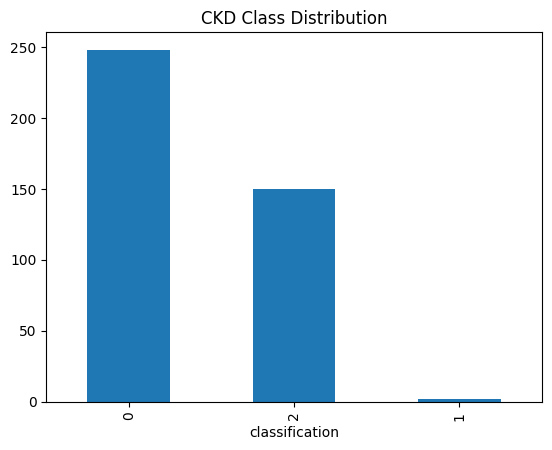

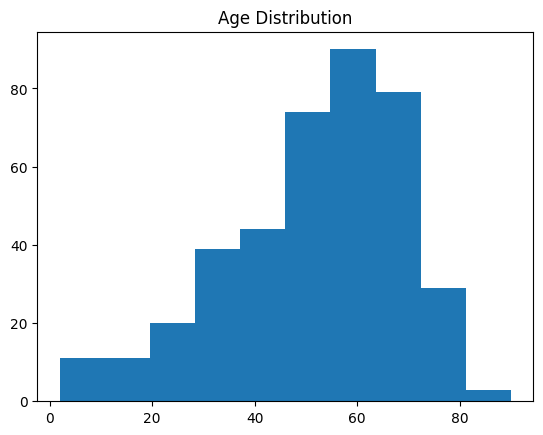

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           2       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

[[52  0]
 [ 0 28]]
['.config', 'kidney_disease.csv', 'sample_data']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# Error: FileNotFoundError. Please upload 'kidney_disease.csv' to your Colab environment or provide the correct path.
df = pd.read_csv("kidney_disease.csv")
df.head()

df.shape

df.info()

df.describe()

df.columns

df.isnull().sum()

df = df.fillna(method='ffill')

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column].astype(str))

        df['classification'].value_counts().plot(kind='bar')
plt.title("CKD Class Distribution")
plt.show()

plt.hist(df['age'])
plt.title("Age Distribution")
plt.show()

X = df.drop("classification", axis=1)

y = df["classification"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

print(classification_report(y_test, prediction))

print(confusion_matrix(y_test, prediction))

# new_patient must have 25 features to match the training data (X).
# The features in order are: 'id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'
new_patient = [[
    # Example values (replace with actual patient data for 25 features)
    0, # id (example)
    48, # age
    80, # bp
    1.02, # sg
    1.0, # al
    0.0, # su
    0, # rbc (example: encoded)
    0, # pc (example: encoded)
    0, # pcc (example: encoded)
    0, # ba (example: encoded)
    121.0, # bgr
    36.0, # bu
    1.2, # sc
    137.5, # sod
    4.7, # pot
    15.4, # hemo
    44, # pcv (example: encoded)
    7800, # wc (example: encoded)
    5.2, # rc (example: encoded)
    0, # htn (example: encoded)
    0, # dm (example: encoded)
    0, # cad (example: encoded)
    0, # appet (example: encoded)
    0, # pe (example: encoded)
    0  # ane (example: encoded)
]]

model.predict(new_patient)

import os

print(os.listdir())